# Temperature Autoregression — a leak-free evaluation walkthrough

This notebook is a self-contained walkthrough of the **`swedish-temperatures:ar`**
problem in [emflow](https://github.com/rebase-energy/emflow): a least-squares
**autoregressive (AR)** model that forecasts hourly air temperature **one hour
ahead** for the SMHI station *Stockholm-Observatoriekullen A*.

The model is trained on all data **before 2026** and evaluated on **2026**.

> **The point of this notebook:** to make it *unmistakably clear that the
> evaluation has no data leakage*. Every claim below is backed by a runnable
> `assert` — if the evaluation leaked, a cell would fail.

All data is bundled inside the `emflow` package, so this notebook runs
top-to-bottom **offline** — no network access required.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rebase-energy/emflow/blob/main/docs/notebooks/swedish_temperatures.ipynb)

In [ ]:
# On Colab, uncomment to install the package (the dataset ships with it):
# !pip install emflow

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import emflow as ef
from emflow.examples.swedish_temperatures.predictor import ARPredictor
from emflow.problems.objective import MeanSquaredError

## 1. Load the problem

`emflow` problems are loaded by name. Each returns a `(dataset, environment,
objective)` triple. The dataset (a single Parquet file) is bundled in the
package and read via `importlib.resources` — nothing is downloaded.

In [ ]:
ef.list_problems()

['gefcom2014-solar:simple',
 'heftcom2024:baseline',
 'solar-battery',
 'swedish-temperatures:ar']

In [ ]:
dataset, env, obj = ef.load_problem("swedish-temperatures:ar")

print(dataset.description)
print()
temps = dataset.data["temperatures"]
series = temps.iloc[:, 0]                      # the Stockholm temperature series
print("Station   :", temps.columns[0])
print("Full range:", series.index.min(), "->", series.index.max())
print("Objective :", obj.name)

Hourly air temperature (°C) from SMHI station Stockholm-Observatoriekullen A (id 98230). Benchmark for 1-step-ahead autoregressive forecasting: train < 2026, evaluate on 2026.

Station   : ('98230', 'Stockholm-Observatoriekullen A')
Full range: 2016-06-02 08:00:00+00:00 -> 2026-06-02 08:00:00+00:00
Objective : MeanAbsoluteError


## 2. Explore the data

Ten years of hourly temperatures. The red line marks `TEST_START` (2026-01-01):
everything to its left is available for training, everything to its right is the
evaluation period.

Note the honest caveat: SMHI's *corrected-archive* (quality-controlled) data ends
~3 months before "now", so the **actual** observations stop on 2026-03-01. The
later 2026 rows exist but are `NaN` and are simply skipped when scoring.

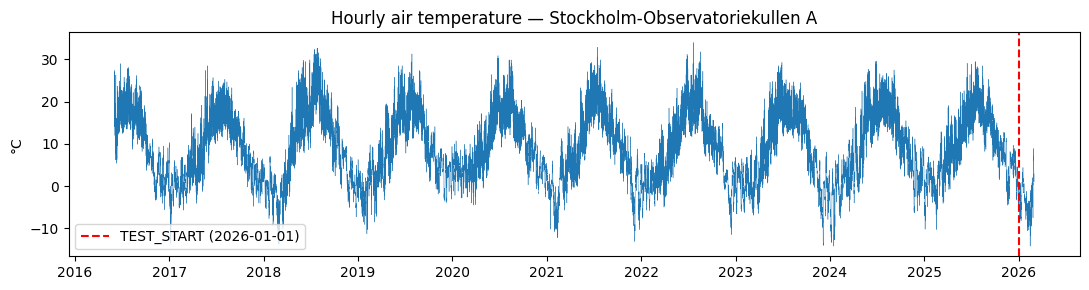

Last real observation: 2026-03-01 06:00:00+00:00


In [ ]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(series.index, series.values, lw=0.3)
ax.axvline(env.test_start, color="red", ls="--", lw=1.5, label="TEST_START (2026-01-01)")
ax.set_title("Hourly air temperature — Stockholm-Observatoriekullen A")
ax.set_ylabel("°C"); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

print("Last real observation:", series.last_valid_index())

## 3. The evaluation contract — what the model is (and isn't) allowed to see

The environment enforces the train/test boundary:

- **`env.reset()`** returns the **training** data (`initial_data["target"]`,
  timestamps *before* `TEST_START`) plus a forecast `input`.
- **`env.step()`** returns the **test actuals** — and only *after* we've made our
  predictions.

So the targets we are scored against are handed back *last*. The model never sees
them while fitting or predicting.

In [ ]:
initial_data, forecast_input = env.reset()
train = initial_data["target"]

print("Train rows        :", f"{len(train):,}")
print("Last training hour:", train.index.max())
print("TEST_START        :", env.test_start)

# The model is fit strictly on the past:
assert train.index.max() < env.test_start
print("\nassert train.index.max() < TEST_START  ->  OK")

Train rows        : 83,992
Last training hour: 2025-12-31 23:00:00+00:00
TEST_START        : 2026-01-01 00:00:00+00:00

assert train.index.max() < TEST_START  ->  OK


## 4. The autoregressive model

`ARPredictor` fits an ordinary-least-squares AR model

$$\hat{y}_t = c + \sum_i w_i\, y_{t-\ell_i}, \qquad \ell \in \{1,\dots,24\}\cup\{168\}$$

i.e. the previous 24 hours plus the same hour one week earlier, with an intercept.
It is plain `numpy.linalg.lstsq` — **no scaler or normalizer** is fit on the data,
so no global/test statistic can sneak in.

In [ ]:
model = ARPredictor()           # lags = [1..24, 168]
model.train(train)              # <-- fit on TRAIN ONLY

col = train.columns[0]
intercept, weights = model.coefs[col]
print("lags          :", model.lags)
print("n parameters  :", len(weights) + 1, "(intercept + lags)")
print("intercept     :", round(intercept, 4))
print("lag-1 weight  :", round(float(weights[model.lags.index(1)]), 4))
print("largest |w| at: lag", model.lags[int(np.abs(weights).argmax())],
      "(temperature is highly persistent)")

lags          : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 168]
n parameters  : 26 (intercept + lags)
intercept     : 0.0115
lag-1 weight  : 1.2349
largest |w| at: lag 1 (temperature is highly persistent)


## 5. Forecast and evaluate on 2026

We predict, *then* call `env.step()` to reveal the actuals, then score. We compare
the AR model against two naive baselines on the **same** test hours:

- **Persistence:** $\hat{y}_t = y_{t-1}$
- **Seasonal-naive (24h):** $\hat{y}_t = y_{t-24}$

In [ ]:
preds = model.predict(forecast_input)          # 1-step-ahead forecasts
_, test_target, done = env.step()              # actuals revealed now

y    = test_target.iloc[:, 0]
yhat = preds.iloc[:, 0].reindex(y.index)
persistence = series.shift(1).reindex(y.index)
seasonal    = series.shift(24).reindex(y.index)

mse = MeanSquaredError()
def score(p):
    return obj.calculate(y, p), mse.calculate(y, p, squared=False)   # MAE, RMSE

results = pd.DataFrame(
    {"AR (lags 1-24+168)": score(yhat),
     "Persistence (t-1)":  score(persistence),
     "Seasonal naive (t-24)": score(seasonal)},
    index=["MAE (°C)", "RMSE (°C)"],
).T.round(3)

n_eval = int(y.reindex(yhat.index).notna().sum())
print(f"Evaluated on {n_eval:,} non-missing test hours (2026)")
results

Evaluated on 1,423 non-missing test hours (2026)


,MAE (°C),RMSE (°C)
AR (lags 1-24+168),0.289,0.399
Persistence (t-1),0.313,0.455
Seasonal naive (t-24),2.261,2.937


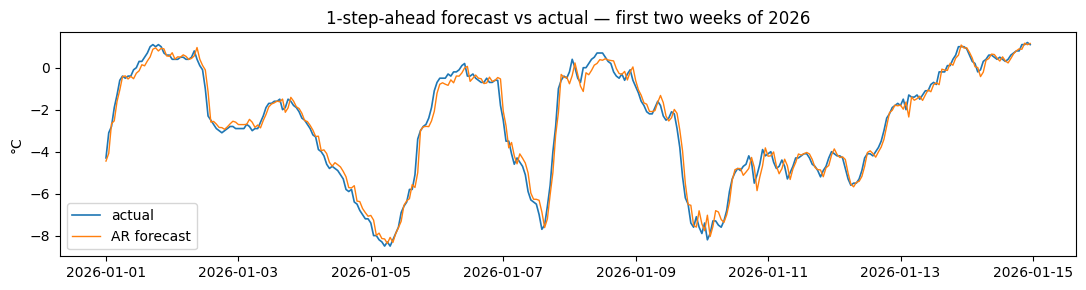

In [ ]:
win = slice("2026-01-01", "2026-01-14")
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(y.loc[win].index, y.loc[win].values, label="actual", lw=1.2)
ax.plot(yhat.loc[win].index, yhat.loc[win].values, label="AR forecast", lw=1.0)
ax.set_title("1-step-ahead forecast vs actual — first two weeks of 2026")
ax.set_ylabel("°C"); ax.legend()
plt.tight_layout(); plt.show()

## 6. No data leakage — demonstrated

It can *look* suspicious that `env.reset()` hands the predictor the **full** series
(including the test period). Below we prove that this is purely a vectorization
convenience and **cannot leak**: every forecast $\hat{y}_t$ depends only on
observations strictly *before* $t$.

### (a) The train and test windows are disjoint

train: 2016-06-02 08:00:00+00:00 -> 2025-12-31 23:00:00+00:00
test : 2026-01-01 00:00:00+00:00 -> 2026-06-02 08:00:00+00:00
overlap: 0 hours


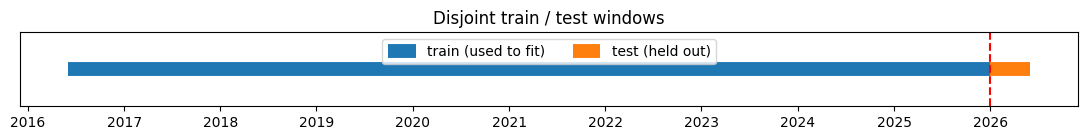

In [ ]:
train_idx, test_idx = train.index, y.index
assert train_idx.max() < env.test_start <= test_idx.min()
assert len(train_idx.intersection(test_idx)) == 0
print("train:", train_idx.min(), "->", train_idx.max())
print("test :", test_idx.min(), "->", test_idx.max())
print("overlap:", len(train_idx.intersection(test_idx)), "hours")

fig, ax = plt.subplots(figsize=(11, 1.5))
ax.hlines(1, train_idx.min(), train_idx.max(), color="C0", lw=10, label="train (used to fit)")
ax.hlines(1, test_idx.min(),  test_idx.max(),  color="C1", lw=10, label="test (held out)")
ax.axvline(env.test_start, color="red", ls="--")
ax.set_yticks([]); ax.legend(loc="upper center", ncol=2); ax.set_title("Disjoint train / test windows")
plt.tight_layout(); plt.show()

### (b) The model was fit on the past only

`model.train(train)` received data ending at the last training hour below — months
before any test timestamp.

In [ ]:
print("model.train() input ended at:", train.index.max())
print("first test timestamp        :", test_idx.min())
assert train.index.max() < test_idx.min()
print("OK — fit data strictly precedes the evaluation period.")

model.train() input ended at: 2025-12-31 23:00:00+00:00
first test timestamp        : 2026-01-01 00:00:00+00:00
OK — fit data strictly precedes the evaluation period.


### (c) Each forecast uses strictly past lags

To predict the very first test hour, the model only references earlier timestamps
(the previous 24 hours and 168h earlier) — all of which fall in the **training**
period.

In [ ]:
t0 = test_idx.min()
lag_times = [t0 - pd.Timedelta(hours=L) for L in model.lags]
assert all(lt < t0 for lt in lag_times)
print("To predict", t0, "the model uses (all strictly earlier):")
print("  ", [str(lag_times[0]), str(lag_times[1]), "...", str(lag_times[-1])])
print("  all < t and all in the training period:", all(lt < env.test_start for lt in lag_times))

To predict 2026-01-01 00:00:00+00:00 the model uses (all strictly earlier):
   ['2025-12-31 23:00:00+00:00', '2025-12-31 22:00:00+00:00', '...', '2025-12-25 00:00:00+00:00']
  all < t and all in the training period: True


### (d) The whole supervised dataset in one picture

Here is the most direct way to *see* there is no leakage. Each 1-step-ahead
prediction is one **sample**: its **inputs** are the lag timestamps
$\{t-1,\dots,t-24,\,t-168\}$ and its **output** is the target time $t$. We loop over
target hours straddling the train/test boundary, collect each sample, and plot the
times: x-axis = sample, y-axis = time, with one colour for inputs and one for outputs.

Read the chart two ways:

- For **every** sample (every x), all input points lie **below** the output point —
  the model only ever looks **back** in time. (Leakage would be an input *above* its
  output; that never happens.)
- The **green** region holds samples whose target is *before* `TEST_START` — these
  (input → output) pairs are exactly the rows `model.train()` was fit on. The **red**
  region holds samples *predicted but never trained on* (the 2026 test set).

In [ ]:
# Build one (output_time, input_times) sample per prediction, around the boundary.
window = pd.Timedelta(hours=100)
targets = series.index[(series.index >= env.test_start - window) &
                       (series.index <= env.test_start + window)]

samples = []                                   # (output_time, input_times)
for t in targets:
    input_times = pd.DatetimeIndex([t - pd.Timedelta(hours=L) for L in model.lags])
    if series.reindex(input_times).notna().all() and pd.notna(series.loc[t]):
        samples.append((t, input_times))       # a genuine design-matrix row

# The ridiculously-easy leakage check: every input is strictly before its output.
assert all(input_times.max() < t for t, input_times in samples)
n_train = sum(t < env.test_start for t, _ in samples)
print(f"{len(samples)} samples ({n_train} train, {len(samples) - n_train} test) — "
      "for EVERY one, all inputs precede the output. ✓")

201 samples (100 train, 101 test) — for EVERY one, all inputs precede the output. ✓

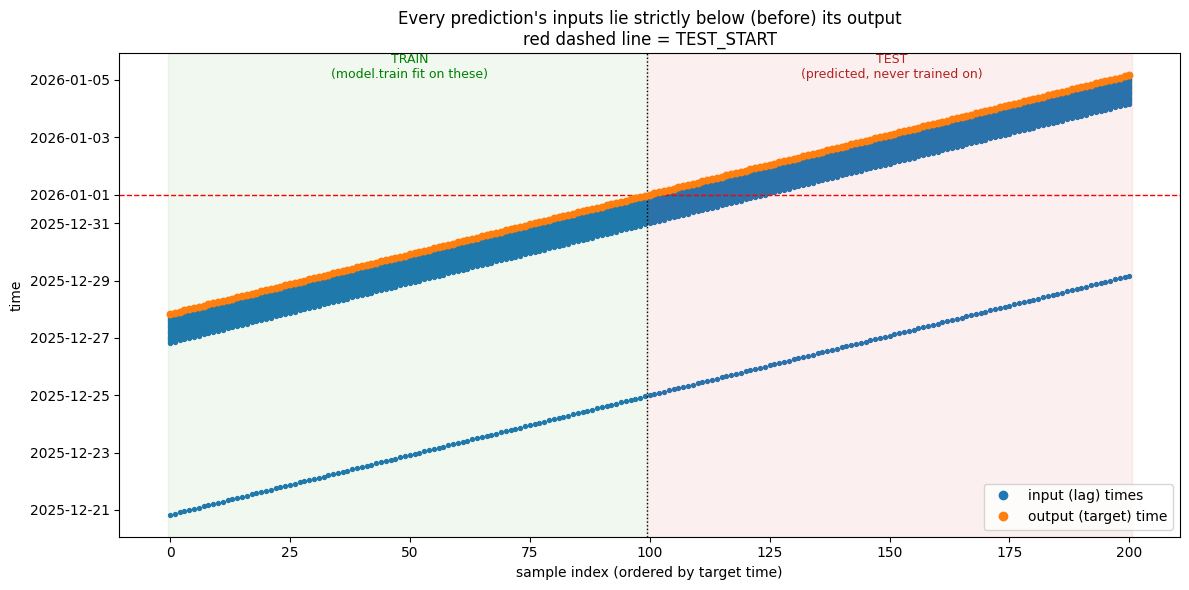

In [ ]:
naive = lambda ts: pd.DatetimeIndex(ts).tz_convert(None)   # drop tz for plotting only

fig, ax = plt.subplots(figsize=(12, 6))
for x, (t, input_times) in enumerate(samples):
    ax.scatter([x] * len(input_times), naive(input_times), s=8, color="tab:blue")
    ax.scatter([x], naive([t]), s=22, color="tab:orange", zorder=3)

# Train vs test shown via background regions (keeps just two point colours).
ax.axvspan(-0.5, n_train - 0.5, color="tab:green", alpha=0.07)
ax.axvspan(n_train - 0.5, len(samples) - 0.5, color="tab:red", alpha=0.07)
ax.axvline(n_train - 0.5, color="black", ls=":", lw=1)
ax.axhline(pd.Timestamp(env.test_start).tz_convert(None), color="red", ls="--", lw=1)

ymax = ax.get_ylim()[1]
ax.text(n_train * 0.5, ymax, "TRAIN\n(model.train fit on these)",
        ha="center", va="top", color="green", fontsize=9)
ax.text((n_train + len(samples)) * 0.5, ymax, "TEST\n(predicted, never trained on)",
        ha="center", va="top", color="firebrick", fontsize=9)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], marker="o", ls="", color="tab:blue", label="input (lag) times"),
    Line2D([0], [0], marker="o", ls="", color="tab:orange", label="output (target) time"),
], loc="lower right")
ax.set_xlabel("sample index (ordered by target time)")
ax.set_ylabel("time")
ax.set_title("Every prediction's inputs lie strictly below (before) its output\n"
             "red dashed line = TEST_START")
plt.tight_layout(); plt.show()

Notice that the **test** samples (red region) have inputs dipping *below* the
`TEST_START` line: they legitimately use already-observed history as lags. That is
allowed — what matters is that no input ever sits *above* its own output.

### (e) Causality proof: hide the present and future, predictions don't change

For a set of test timestamps $t^\*$, we recompute the forecast from a copy of the
series in which **every value at $t \ge t^\*$ is deleted** (set to `NaN`). If a
prediction secretly used present/future information, it would change. It does not:
the maximum difference is exactly **0**.

In [ ]:
full_pred = model.predict(forecast_input).iloc[:, 0]

def predict_with_future_hidden(cutoff):
    masked = forecast_input.copy()
    masked.loc[masked.index >= cutoff] = np.nan     # hide present + future
    return model.predict(masked).iloc[:, 0]

# Sample test hours that actually have a forecast (most of Mar-Jun 2026 is NaN),
# always including the very first test hour. Sample by position to keep tz info.
rng = np.random.default_rng(0)
predictable = full_pred.dropna().index
predictable = predictable[predictable >= env.test_start]
pos = rng.choice(len(predictable), size=min(50, len(predictable)), replace=False)
sample = [test_idx.min()] + [predictable[p] for p in pos]

max_diff, n_checked = 0.0, 0
for t in sample:
    a = full_pred.loc[t]
    b = predict_with_future_hidden(t).loc[t]
    if np.isnan(a) and np.isnan(b):
        continue                                    # lag genuinely missing in both
    max_diff = max(max_diff, abs(float(a) - float(b)))
    n_checked += 1

print(f"checked {n_checked} test hours")
print("max |Δ| between full-series and future-hidden forecasts:", max_diff)
assert max_diff == 0.0
print("✓ Every forecast depends only on strictly past observations — no leakage.")

checked 51 test hours
max |Δ| between full-series and future-hidden forecasts: 0.0
✓ Every forecast depends only on strictly past observations — no leakage.


### (f) Corrupting *every* test actual leaves early forecasts untouched

As a final illustration: add large random noise to **all** test-period values and
re-predict the first test hour. Because its lags lie entirely in the (untouched)
training period, the forecast is byte-for-byte identical.

In [ ]:
noise = pd.DataFrame(0.0, index=forecast_input.index, columns=forecast_input.columns)
m = forecast_input.index >= env.test_start
noise.loc[m] = rng.normal(0, 10, size=(int(m.sum()), forecast_input.shape[1]))
corrupted = forecast_input + noise

orig = model.predict(forecast_input).iloc[:, 0].loc[t0]
corr = model.predict(corrupted).iloc[:, 0].loc[t0]
print("first test-hour forecast — original :", round(float(orig), 6))
print("first test-hour forecast — corrupted:", round(float(corr), 6))
assert orig == corr
print("✓ Corrupting all test actuals does not change the first test forecast.")

first test-hour forecast — original : -4.449448
first test-hour forecast — corrupted: -4.449448
✓ Corrupting all test actuals does not change the first test forecast.


## 7. Recap & next steps

- The split is **disjoint**, the model is **fit on the past only**, there is **no
  preprocessing leak**, and each 1-step-ahead forecast provably uses **strictly past
  lags** — verified above with hard `assert`s.
- The AR model comfortably beats persistence and seasonal-naive baselines.

Ideas to extend this:
- **All 15 stations** — `ARPredictor` already loops over columns; drop the
  single-station selection in the problem to forecast the whole network.
- **Multi-step horizons** — roll the AR forward recursively and watch error grow.
- **Fresher 2026 data** — top up past the 2026-03-01 archive cutoff with SMHI's
  `latest-months` period (note: that tail is provisional, not yet quality-corrected).